In [2]:
import sys
print(sys.executable)

/mnt/c/Users/semi/Plasma_simulation/.venv/bin/python


In [ ]:
import sys
!{sys.executable} -m pip install numpy matplotlib HTML

  Using cached numpy-2.4.6-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
Using cached numpy-2.4.6-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.6 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 2.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 2.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 2.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 2.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [matplotlib]8 [matplotlib]


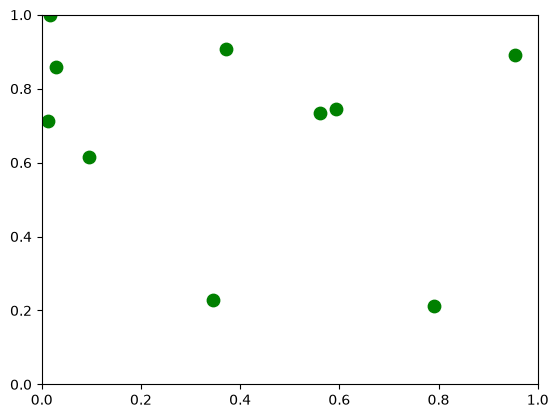

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# ------------------
# Parameters
# ------------------

N = 10
Lx = 1.0
Ly = 1.0

dt = 0.01

# ------------------
# Initial conditions
# ------------------

x = np.random.rand(N) * Lx
y = np.random.rand(N) * Ly

vx = np.random.uniform(-0.3, 0.3, N)
vy = np.random.uniform(-0.3, 0.3, N)

# ------------------
# Plot
# ------------------

fig, ax = plt.subplots()

ax.set_xlim(0, Lx)
ax.set_ylim(0, Ly)

scat = ax.scatter(x, y, s=80, color='green')

# ------------------
# Time stepping
# ------------------

def update(frame):

    global x, y, vx, vy

    x += vx * dt
    y += vy * dt

    # wall reflections

    hit_left = x < 0
    hit_right = x > Lx

    vx[hit_left | hit_right] *= -1

    x = np.clip(x, 0, Lx)

    hit_bottom = y < 0
    hit_top = y > Ly

    vy[hit_bottom | hit_top] *= -1

    y = np.clip(y, 0, Ly)

    scat.set_offsets(np.column_stack((x, y)))

    return scat,

ani = FuncAnimation(
    fig,
    update,
    frames=100,
    interval=20,
    blit=True
)

from IPython.display import HTML

HTML(ani.to_jshtml())